In [2]:
import pandas as pd
import openpyxl

In [3]:
df = pd.read_csv(r"c:\Users\DELL\OneDrive\Documents\finance_economics_dataset.csv")
print(df)

            Date Stock Index  Open Price  Close Price  Daily High  Daily Low  \
0     01-01-2000   Dow Jones     2128.75      2138.48     2143.70    2100.55   
1     02-01-2000     S&P 500     2046.82      2036.18     2082.83    2009.53   
2     03-01-2000   Dow Jones     1987.92      1985.26     2022.28    1978.37   
3     04-01-2000   Dow Jones     4625.02      4660.47     4665.26    4595.46   
4     05-01-2000     S&P 500     1998.18      1982.18     2044.31    1966.44   
...          ...         ...         ...          ...         ...        ...   
2995  14-03-2008   Dow Jones     1273.76      1235.44     1317.28    1192.34   
2996  15-03-2008     S&P 500     4589.59      4566.91     4607.56    4545.69   
2997  16-03-2008     S&P 500     1477.52      1448.47     1523.86    1402.69   
2998  17-03-2008      NASDAQ     2311.37      2306.90     2346.30    2282.00   
2999  18-03-2008      NASDAQ     4262.98      4303.82     4316.68    4243.04   

      Trading Volume  GDP Growth (%)  I

1. What is the shape of the dataset?

In [3]:
df.shape

(3000, 24)

2. What are the column names and their data types?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Date                                   3000 non-null   object 
 1   Stock Index                            3000 non-null   object 
 2   Open Price                             3000 non-null   float64
 3   Close Price                            3000 non-null   float64
 4   Daily High                             3000 non-null   float64
 5   Daily Low                              3000 non-null   float64
 6   Trading Volume                         3000 non-null   int64  
 7   GDP Growth (%)                         3000 non-null   float64
 8   Inflation Rate (%)                     3000 non-null   float64
 9   Unemployment Rate (%)                  3000 non-null   float64
 10  Interest Rate (%)                      3000 non-null   float64
 11  Cons

In [6]:
df.dtypes

Date                                      object
Stock Index                               object
Open Price                               float64
Close Price                              float64
Daily High                               float64
Daily Low                                float64
Trading Volume                             int64
GDP Growth (%)                           float64
Inflation Rate (%)                       float64
Unemployment Rate (%)                    float64
Interest Rate (%)                        float64
Consumer Confidence Index                  int64
Government Debt (Billion USD)              int64
Corporate Profits (Billion USD)            int64
Forex USD/EUR                            float64
Forex USD/JPY                            float64
Crude Oil Price (USD per Barrel)         float64
Gold Price (USD per Ounce)               float64
Real Estate Index                        float64
Retail Sales (Billion USD)                 int64
Bankruptcy Rate (%) 

3. How many unique stock indices are there?

In [7]:
df["Stock Index"].nunique()

3

4. What is the date range of the dataset?


In [9]:
df["Date"].min() , df["Date"].max()

(Timestamp('2000-01-01 00:00:00'), Timestamp('2008-03-18 00:00:00'))

5. Are there any missing values?

In [10]:
df.isnull().sum()

Date                                     0
Stock Index                              0
Open Price                               0
Close Price                              0
Daily High                               0
Daily Low                                0
Trading Volume                           0
GDP Growth (%)                           0
Inflation Rate (%)                       0
Unemployment Rate (%)                    0
Interest Rate (%)                        0
Consumer Confidence Index                0
Government Debt (Billion USD)            0
Corporate Profits (Billion USD)          0
Forex USD/EUR                            0
Forex USD/JPY                            0
Crude Oil Price (USD per Barrel)         0
Gold Price (USD per Ounce)               0
Real Estate Index                        0
Retail Sales (Billion USD)               0
Bankruptcy Rate (%)                      0
Mergers & Acquisitions Deals             0
Venture Capital Funding (Billion USD)    0
Consumer Sp

6. Are there negative values in columns that should be non-negative?

In [11]:
(df[["Open Price","Close Price","Daily High","Daily Low",
     "Trading Volume","Crude Oil Price (USD per Barrel)",
     "Gold Price (USD per Ounce)"]] < 0).sum()


Open Price                          0
Close Price                         0
Daily High                          0
Daily Low                           0
Trading Volume                      0
Crude Oil Price (USD per Barrel)    0
Gold Price (USD per Ounce)          0
dtype: int64

7. What is the summary of GDP Growth (%)?

In [12]:
df["GDP Growth (%)"].describe()

count    3000.000000
mean        2.608903
std         4.287337
min        -5.000000
25%        -1.012500
50%         2.725000
75%         6.242500
max        10.000000
Name: GDP Growth (%), dtype: float64

8. Are there rows with zero or near-zero trading volume?

In [13]:
(df["Trading Volume"] == 0).sum()


np.int64(0)

9. Are there any duplicate rows?


In [14]:
df.duplicated().sum()

np.int64(0)

10. Are there outliers in GDP, Gold, or Oil prices?

In [15]:
df[["GDP Growth (%)",
    "Gold Price (USD per Ounce)",
    "Crude Oil Price (USD per Barrel)"]].describe()


,GDP Growth (%),Gold Price (USD per Ounce),Crude Oil Price (USD per Barrel)
count,3000.000000,3000.000000,3000.000000
mean,2.608903,1655.167877,85.539953
std,4.287337,492.177706,37.847063
min,-5.000000,800.160000,20.040000
25%,-1.012500,1226.737500,52.590000
50%,2.725000,1666.060000,85.080000
75%,6.242500,2080.730000,119.150000
max,10.000000,2499.660000,149.870000


11. What is the summary of Inflation Rate (%)?

In [16]:
df["Inflation Rate (%)"].describe()

count    3000.000000
mean        5.096830
std         2.910513
min         0.010000
25%         2.607500
50%         5.110000
75%         7.600000
max        10.000000
Name: Inflation Rate (%), dtype: float64

12. What is the average unemployment rate?


In [17]:
df["Unemployment Rate (%)"].mean()

np.float64(8.663786666666667)

13. Which index has the highest trading volume?


In [18]:
df["Trading Volume"].max()

999977078

14. How many stock records are from each index?

In [19]:
df.groupby("Stock Index")["Trading Volume"].sum()


Stock Index
Dow Jones    477653121048
NASDAQ       499464048465
S&P 500      533041986803
Name: Trading Volume, dtype: int64

15. What is the correlation between inflation and interest rate?


In [22]:
df["Stock Index"].value_counts()

Stock Index
S&P 500      1036
NASDAQ       1007
Dow Jones     957
Name: count, dtype: int64

16. What is the average Consumer Confidence Index?

In [23]:
df["Inflation Rate (%)"].corr(df["Interest Rate (%)"])

np.float64(0.005732927235576232)

17. Which column has the highest standard deviation?

In [24]:
df["Consumer Confidence Index"].mean()

np.float64(85.036)

In [25]:
df.std(numeric_only=True).idxmax()


'Trading Volume'

18. What is the highest gold price recorded?


In [26]:
df["Gold Price (USD per Ounce)"].mean()

np.float64(1655.1678766666666)

19. Which date had the highest crude oil price?

In [27]:
df.loc[df["Crude Oil Price (USD per Barrel)"].idxmax(), "Date"]


Timestamp('2001-11-22 00:00:00')

20. What is the average corporate profit?

In [28]:
df["Corporate Profits (Billion USD)"].mean()

np.float64(2553.7563333333333)

Insightful Analysis Questions

1. What percentage of the dataset shows negative GDP growth?

In [29]:
negative_gdp = df[df["GDP Growth (%)"] < 0].shape[0]
total = df.shape[0]

percentage = (negative_gdp / total) * 100
percentage


31.566666666666666

2. Does high inflation correspond to higher interest rates?


In [30]:
df["Inflation Rate (%)"].corr(df["Interest Rate (%)"])

np.float64(0.005732927235576232)

3. Is there a relationship between unemployment and consumer spending?

In [31]:
df["Unemployment Rate (%)"].corr(df["Consumer Confidence Index"])

np.float64(0.01146422372117294)

4. Do higher corporate profits align with higher consumer confidence?

In [32]:
df["Corporate Profits (Billion USD)"].corr(df["Consumer Confidence Index"])

np.float64(0.0180080558882696)

5. What’s the trend of crude oil prices over time?

<Axes: xlabel='Date'>

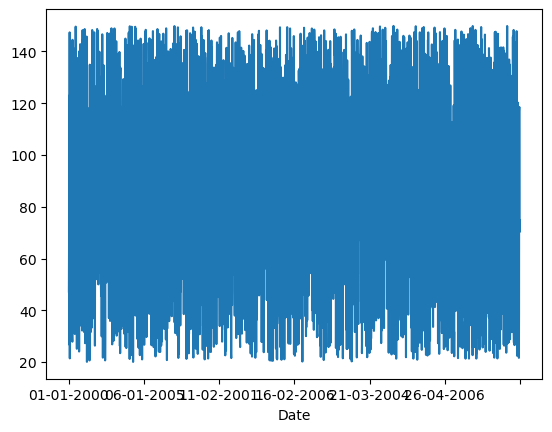

In [7]:
df["Crude Oil Price (USD per Barrel)"].groupby(df["Date"]).mean().plot()

6. Are gold prices inversely related to stock performance

In [9]:
df["Gold Price (USD per Ounce)"].corr(df["Close Price"])

np.float64(-0.014543960422329267)

7. Does government debt impact consumer confidence?

In [12]:
df["Government Debt (Billion USD)"].corr(df["Consumer Confidence Index"])

np.float64(-0.03637006085825002)

8. How do mergers & acquisitions (M&A) activity correlate with stock index closing prices?

In [13]:
df["Mergers & Acquisitions Deals"].corr(df["Close Price"])

np.float64(0.0026371007894390383)

9. Is retail sales growth associated with GDP growth?

In [14]:
df["Retail Sales (Billion USD)"].corr(df["GDP Growth (%)"])

np.float64(-0.014287611445719916)

10. Is stock market performance linked to consumer spending?

In [15]:
df["Close Price"].corr(df["Consumer Confidence Index"])

np.float64(0.013481851433761148)

11. Which stock index had the highest average closing price?


In [17]:
df.groupby("Stock Index")["Close Price"].mean()


Stock Index
Dow Jones    3004.456447
NASDAQ       2985.905015
S&P 500      2955.286052
Name: Close Price, dtype: float64

12. What is the relationship between interest rate and unemployment?

In [18]:
df["Interest Rate (%)"].corr(df["Unemployment Rate (%)"])


np.float64(0.018004072130972777)

13. Do lower consumer confidence values coincide with higher bankruptcy rates?

In [19]:
df["Consumer Confidence Index"].corr(df["Bankruptcy Rate (%)"])


np.float64(-0.01631304347909408)

14. Which indicator has the highest correlation with stock close price?


In [20]:
df.corr(numeric_only=True)["Close Price"].sort_values(ascending=False)


Close Price                              1.000000
Daily High                               0.999821
Daily Low                                0.999820
Open Price                               0.999688
Retail Sales (Billion USD)               0.049370
Bankruptcy Rate (%)                      0.029380
Venture Capital Funding (Billion USD)    0.021414
Interest Rate (%)                        0.020434
Trading Volume                           0.016283
Consumer Confidence Index                0.013482
Corporate Profits (Billion USD)          0.008797
Mergers & Acquisitions Deals             0.002637
Crude Oil Price (USD per Barrel)         0.002563
Consumer Spending (Billion USD)          0.000376
Unemployment Rate (%)                   -0.001907
Government Debt (Billion USD)           -0.007332
Inflation Rate (%)                      -0.007972
Real Estate Index                       -0.008639
GDP Growth (%)                          -0.012748
Gold Price (USD per Ounce)              -0.014544


15. Are unemployment rates lower when corporate profits are high?

In [22]:
df["Corporate Profits (Billion USD)"].corr(df["Unemployment Rate (%)"])


np.float64(0.008292414188235573)

Retail Sales Analysis

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r"c:\Users\DELL\Downloads\Retail Data.csv")
print(df)

     Order No  Order Date           Customer Name  \
0      4293-1  02-09-2014        Vivek Sundaresam   
1      5001-1  24-10-2015          Shahid Hopkins   
2      5004-1  13-03-2014           Dennis Pardue   
3      5009-1  18-02-2013              Sean Wendt   
4      5010-1  13-09-2014  Christina Vanderzanden   
...       ...         ...                     ...   
4995   6831-1  02-11-2016           Roland Murray   
4996   6847-1  16-12-2015          Patrick OBrill   
4997   6922-1  28-09-2016            Troy Staebel   
4998   6939-1  18-06-2016             Shaun Weien   
4999   6980-1  12-08-2015          Nora Pelletier   

                                  Address       City State   Customer Type  \
0          152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1           438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2                412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3                145 Ramsay St,Haberfield     Sydne

1. View the structure of the dataset (columns, types, missing values).

In [13]:
# 1. View dataset structure (columns and data types)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

In [15]:
# 2. Check missing values
df.isnull().sum()

Order No             0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       1
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64

2. What is the shape (rows, columns) of the dataset?

In [17]:
df.shape

(5000, 24)

3. Are there any duplicate records?\

In [18]:
df.duplicated().sum()

np.int64(0)

4. Are there any missing or corrupted entries in Ship Date, Order Date, or numeric
columns?


In [ ]:
df["Cost Price"].isnull().sum()
df["Retail Price"].isnull().sum()
df["Order Quantity"].isnull().sum()
df["Total"].isnull().sum()

np.int64(0)

5. Convert Order Date and Ship Date to datetime

In [24]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")
df[["Order Date","Ship Date"]].head()

,Order Date,Ship Date
0,2014-02-09,2014-04-09
1,NaT,NaT
2,NaT,NaT
3,NaT,NaT
4,NaT,NaT


6. Check for future or inconsistent shipping dates

In [4]:
df[df["Ship Date"] < df["Order Date"]]

,Order No,Order Date,Customer Name,Address,City,State,Customer Type,Account Manager,Order Priority,Product Name,...,Cost Price,Retail Price,Profit Margin,Order Quantity,Sub Total,Discount %,Discount $,Order Total,Shipping Cost,Total
12,5018-1,29-12-2013,Lena Creighton,"127 Liverpool St,Sydney",Sydney,NSW,Small Business,Samantha Chairs,Low,TypeRight Side-Opening Peel & Seel Expanding E...,...,$54.29,$90.48,$36.19,1.0,"$1,029.50",2%,$30.82,"$1,762.54",$19.99,"$1,740.57"
44,5025-1,30-07-2014,Denny Joy,"99 Lygon Street,East Brunswick",Melbourne,VIC,Consumer,Connor Betts,Not Specified,Smiths General Use 3-Ring Binders,...,$1.18,$1.88,$0.70,39.0,$35.70,9%,$3.51,$34.53,$1.49,$35.33
46,5026-1,31-05-2013,Raymond Fair,"188 Pitt Street,Sydney",Sydney,NSW,Home Office,Tina Carlton,High,Artisan 479 Labels,...,$1.59,$2.61,$1.02,41.0,$23.29,5%,$1.61,$22.29,$0.50,$22.69
70,5035-1,30-04-2013,Pamela Stobb,"273 George Street,Sydney",Sydney,NSW,Consumer,Leighton Forrest,Low,HFX LaserJet 3310 Copier,...,$377.99,$599.99,$222.00,35.0,"$2,065.80",5%,$54.07,"$2,759.75",$24.49,"$2,761.25"
74,5037-1,29-06-2013,Adam Bellavance,"106 Ebley Street,Bondi Junction",Sydney,NSW,Home Office,Leighton Forrest,Not Specified,Apex Elite Stainless Steel Scissors,...,$3.42,$8.34,$4.92,11.0,$133.44,7%,$4.00,$129.44,$2.64,$132.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4959,6574-1,30-01-2017,Michelle Huthwait,"834 Bourke Street,Darlinghurst",Sydney,NSW,Corporate,Charlie Bui,Medium,Adesso Programmable 142-Key Keyboard,...,$32.02,$152.48,$120.46,39.0,$622.34,4%,$32.73,$660.83,$4.00,$678.48
4970,6584-1,29-06-2016,Brian DeCherney,"523 King St,Newtown",Sydney,NSW,Consumer,Aanya Zhang,Medium,HFX LaserJet 3310 Copier,...,$377.99,$599.99,$222.00,12.0,"$5,080.74",0%,$0.00,"$5,080.54",$24.49,"$5,027.54"
4971,6584-1,26-09-2016,Mike Kennedy,"99 Lygon Street,East Brunswick",Melbourne,VIC,Corporate,Connor Betts,Medium,HFX LaserJet 3310 Copier,...,$377.99,$599.99,$222.00,50.0,"$3,805.48",10%,$322.71,"$3,635.89",$24.49,"$3,601.40"
4972,6584-1,24-08-2015,Michael Oakman,"8 Rankins Lane ,Melbourne",Melbourne,VIC,Consumer,Connor Betts,Low,Artisan Durable Binders,...,$1.84,$2.88,$1.04,19.0,$43.78,9%,$4.06,$42.14,$1.49,$43.93


7. Convert price columns to numeric (remove $ and commas).

In [7]:
df[["Cost Price","Retail Price","Total"]] = df[["Cost Price","Retail Price","Total"]].replace('[\$,]', '', regex=True).astype(float)
print(df)

     Order No  Order Date           Customer Name  \
0      4293-1  02-09-2014        Vivek Sundaresam   
1      5001-1  24-10-2015          Shahid Hopkins   
2      5004-1  13-03-2014           Dennis Pardue   
3      5009-1  18-02-2013              Sean Wendt   
4      5010-1  13-09-2014  Christina Vanderzanden   
...       ...         ...                     ...   
4995   6831-1  02-11-2016           Roland Murray   
4996   6847-1  16-12-2015          Patrick OBrill   
4997   6922-1  28-09-2016            Troy Staebel   
4998   6939-1  18-06-2016             Shaun Weien   
4999   6980-1  12-08-2015          Nora Pelletier   

                                  Address       City State   Customer Type  \
0          152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1           438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2                412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3                145 Ramsay St,Haberfield     Sydne

8. What are the unique values in Customer Type and Order Priority?

In [10]:
df["Customer Type"].unique(), df["Order Priority"].unique()

(array(['Small Business', 'Corporate', 'Consumer', 'Home Office'],
       dtype=object),
 array(['Critical', 'Medium', 'Not Specified', 'Low', 'High'], dtype=object))

9. What are the most common shipping modes?

In [9]:
df["Ship Mode"].value_counts()

Ship Mode
Regular Air       4236
Express Air        647
Delivery Truck     117
Name: count, dtype: int64

10. Which cities have the highest number of orders?

In [11]:
df["City"].value_counts()

City
Sydney       3584
Melbourne    1416
Name: count, dtype: int64

11. What’s the range of order quantities and prices?

In [12]:
df[["Order Quantity","Total"]].describe()

,Order Quantity,Total
count,4999.000000,5000.00000
mean,26.483097,746.30728
std,14.391863,2283.42573
min,1.000000,2.85000
25%,13.000000,63.46000
50%,27.000000,137.50500
75%,39.000000,407.09750
max,50.000000,26725.06000


12. Create a new column for shipping duration.


In [16]:
df["Shipping Duration"] = (pd.to_datetime(df["Ship Date"],errors="coerce") - pd.to_datetime(df["Order Date"],errors="coerce")).dt.days; print(df[["Order Date","Ship Date","Shipping Duration"]].head())

  Order Date  Ship Date  Shipping Duration
0 2014-02-09 2014-04-09               59.0
1        NaT        NaT                NaN
2        NaT        NaT                NaN
3        NaT        NaT                NaN
4        NaT        NaT                NaN


13. Are there any orders with zero or negative total or quantity?

In [17]:
df["Total"] <= 0 | (df["Order Quantity"] <= 0)

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

14. Are all discount percentages matching discount dollar amounts?

In [26]:
df["Discount $"] = df["Discount $"].str.replace("$","").astype(float); print(df[["Discount %","Discount $"]].head())

  Discount %  Discount $
0         2%      194.83
1         3%        0.00
2         4%       72.23
3         1%        4.35
4         7%        5.95


15. Check for mismatches in total calculation’

In [28]:
df["Total"] != (df["Order Total"] + df["Shipping Cost"])

0       True
1       True
2       True
3       True
4       True
        ... 
4995    True
4996    True
4997    True
4998    True
4999    True
Length: 5000, dtype: bool

16. Identify top 5 products by order quantity

In [29]:
df.groupby("Product Name")["Order Quantity"].sum().sort_values(ascending=False).head(5)

Product Name
Artisan 474 Labels                         3395.0
Smiths General Use 3-Ring Binders          3220.0
Artisan 479 Labels                         3039.0
Artisan 481 Labels                         2996.0
Apex Preferred Stainless Steel Scissors    2896.0
Name: Order Quantity, dtype: float64

17. Which Account Manager handled the most revenue?

In [30]:
df.groupby("Account Manager")["Total"].sum().sort_values(ascending=False).head(1)

Account Manager
Connor Betts    671173.17
Name: Total, dtype: float64

18. What is the average shipping cost by mode?

In [32]:
df["Shipping Cost"] = df["Shipping Cost"].str.replace("[$,]","", regex=True).astype(float); print(df.groupby("Ship Mode")["Shipping Cost"].mean())

Ship Mode
Delivery Truck    5.270085
Express Air       5.247311
Regular Air       5.503553
Name: Shipping Cost, dtype: float64


19. Find the most profitable product.

In [34]:
df.groupby("Product Name")["Profit Margin"].sum().sort_values(ascending=False).head(1)

Product Name
Economy Rollaway Files    $97.47$97.47$97.47$97.47$97.47$97.47$97.47$97....
Name: Profit Margin, dtype: object

20. Find the most profitable product.

In [35]:
df.loc[df["Profit Margin"].idxmax(), "Product Name"]

'Economy Rollaway Files'

Insightful Analysis Questions

1. What is the total revenue generated across all orders?

In [36]:
df["Total"].sum()

np.float64(3731536.4000000004)

2. Which customer type generates more revenue?

In [37]:
df.groupby("Customer Type")["Total"].sum().sort_values(ascending=False)

Customer Type
Corporate         1373796.44
Home Office        851621.96
Small Business     830886.35
Consumer           675231.65
Name: Total, dtype: float64

3. How does order priority affect revenue?

In [4]:
df.groupby("Order Priority")["Total"].sum()

Order Priority
Critical         $4,291.55$730.92$1,705.42$26.46$112.38$4,764.5...
High             $139.46$112.38$112.38$4,592.51$79.44$4,764.51$...
Low              $121.03$1,740.57$35.33$112.38$143.72$233.95$4,...
Medium           $46.91$27.43$1,533.62$23.46$112.38$274.97$4,76...
Not Specified    $82.58$125.97$189.43$60.45$189.45$199.40$694.0...
Name: Total, dtype: object

4. What is the average profit margin by product category?

In [6]:
df["Profit Margin"] = pd.to_numeric(df["Profit Margin"], errors="coerce"); print(df.groupby("Product Category")["Profit Margin"].mean())

Product Category
Furniture         NaN
Office Supplies   NaN
Technology        NaN
Name: Profit Margin, dtype: float64


5. What is the most profitable product overall?

In [7]:
df.groupby("Product Name")["Profit Margin"].sum().idxmax()

'"Adams ""While You Were Out"" Message Pads"'

6. How many days does it usually take to ship an order?

In [10]:
print((pd.to_datetime(df["Ship Date"],errors="coerce") - pd.to_datetime(df["Order Date"],errors="coerce")).dt.days.mean())

50.469746258945996


7. Do longer shipping times impact profit margins?

In [14]:
print((pd.to_datetime(df["Ship Date"],errors="coerce") - pd.to_datetime(df["Order Date"],errors="coerce")).dt.days.corr(pd.to_numeric(df["Profit Margin"],errors="coerce")))

nan


8. Which city brings in the highest revenue?


In [19]:
print(df.groupby('City')['Order Total'].sum().sort_values(ascending=False).head(3))

City
Melbourne    $837.57$178.12$119.83$667.75$657.75$109.98$109...
Sydney       $4,757.22$45.90$740.67$123.77$183.58$59.62$22....
Name: Order Total, dtype: object


9. Which account manager generated the most revenue?

In [21]:
print(df.groupby('Account Manager')['Order Total'].sum().sort_values(ascending=False).head(3))

Account Manager
Connor Betts    $837.57$178.12$119.83$78.46$62.38$53.22$34.53$...
Phoebe Gour     $740.67$23.63$4,744.52$4,744.52$4,744.52$53.22...
Yvette Biti     $667.75$657.75$109.98$109.98$109.98$109.98$122...
Name: Order Total, dtype: object


10. Which shipping mode is most cost-effective (lowest avg. shipping)?

In [23]:
print(pd.to_numeric(df['Shipping Cost'], errors='coerce').groupby(df['Ship Mode']).mean().idxmin())

nan


C:\Users\DELL\AppData\Local\Temp\ipykernel_1672\739790794.py:1: FutureWarning: The behavior of Series.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  print(pd.to_numeric(df['Shipping Cost'], errors='coerce').groupby(df['Ship Mode']).mean().idxmin())


11. Do higher discounts reduce profits?

In [25]:
print(pd.to_numeric(df['Discount $'], errors='coerce').corr(pd.to_numeric(df['Profit Margin'], errors='coerce')))

nan


12. Which state has the highest number of orders?

In [26]:
print(df['State'].value_counts().idxmax())

NSW


13. What is the average discount % across all orders?

In [27]:
print(pd.to_numeric(df['Discount %'], errors='coerce').mean())

nan


14. What is the average total spend per order?

In [28]:
print(pd.to_numeric(df['Order Total'], errors='coerce').mean())

nan


15. . Are certain containers (e.g., Small Box, Wrap Bag) more profitable?

In [30]:
print(df.groupby('Product Container')['Profit Margin'].apply(lambda x: pd.to_numeric(x, errors='coerce').mean()).sort_values(ascending=False))

Product Container
Jumbo Drum   NaN
Large Box    NaN
Medium Box   NaN
Small Box    NaN
Small Pack   NaN
Wrap Bag     NaN
Name: Profit Margin, dtype: float64
